In [35]:
import os
import sys

print("Python", sys.version.split()[0])

for package in ["numpy", "pandas", "matplotlib", "seaborn", "sklearn"]:
    try:
        __import__(package)
        print(f"{package:<12} found")
    except ImportError:
        print(f"{package:<12} MISSING  ->  pip install {package}")

for filename in ["headbrain.csv", "titanic.csv", "diabetes.csv"]:
    path = os.path.join(filename)
    status = "found" if os.path.isfile(path) else "MISSING"
    print(f"{filename:<16} {status}")

Python 3.12.13
numpy        found
pandas       found
matplotlib   found
seaborn      found
sklearn      found
headbrain.csv    found
titanic.csv      found
diabetes.csv     found


**LINEAR REGRESSION**

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Task - A1

In [38]:
class LinearRegression:
    """Simple linear regression by ordinary least squares."""

    def fit(self, X, y):
        """Estimate b0 and b1 from one-dimensional arrays X and y.

        Stores the results as self.b0 and self.b1 and returns self.
        """
        m = X.shape[0]

        # 1. compute the means of X and y
        x_mean = np.mean(X)
        y_mean = np.mean(y)

        # 2. compute the mean-centred vectors
        x_centered = X - x_mean
        y_centered = y - y_mean

        # 3. obtain b1 from the ratio of the two inner products
        self.b1 = np.dot(x_centered, y_centered) / np.dot(x_centered, x_centered)

        # 4. obtain b0 from b1 and the two means
        self.b0 = y_mean - self.b1 * x_mean

        # 6. print the pair and return self
        print(f"(b0, b1) = ({self.b0:.3f}, {self.b1:.3f})")
        return self

    def predict(self, X):
        """Return the predicted response for the array X."""
        return self.b0 + self.b1 * X

    def evaluate(self, X, y):
        """Print and return the RMSE and the R^2 score as a tuple."""
        y_pred = self.predict(X)

        rmse = np.sqrt(np.mean((y - y_pred) ** 2))
        y_mean = np.mean(y)
        ss_tot = np.sum((y - y_mean) ** 2)
        ss_res = np.sum((y - y_pred) ** 2)
        r2 = 1.0 - (ss_res / ss_tot)

        print("Root mean squared error:", round(rmse, 3))
        print("R^2 value:", round(r2, 3))

        return rmse, r2

Task - A2

In [39]:
def regression_plot(X, y, model, title=""):
    """Scatter plot of the data with the fitted regression line drawn over it."""
    plt.figure(figsize=(10, 6))
    plt.title(title)

    # 1. label the x and y axes
    plt.xlabel("Head size (cm^3)")
    plt.ylabel("Brain weight (grams)")

    # 2. build a two-element array x_line spanning slightly beyond the data range
    x_min, x_max = np.min(X), np.max(X)
    margin = (x_max - x_min) * 0.05
    x_line = np.array([x_min - margin, x_max + margin])

    # 3. evaluate model on x_line
    y_line = model.predict(x_line)

    # 4. draw scatter and line plots
    plt.scatter(X, y, alpha=0.6, label="Observed Data")
    plt.plot(x_line, y_line, color="red", linewidth=2, label="Fitted Line")

    # 5. add legend and show
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

Task - A3

Shape: (237, 4)
   Gender  Age Range  Head Size(cm^3)  Brain Weight(grams)
0       1          1             4512                 1530
1       1          1             3738                 1297
2       1          1             4261                 1335
3       1          1             3777                 1282
4       1          1             4177                 1590
(b0, b1) = (325.573, 0.263)


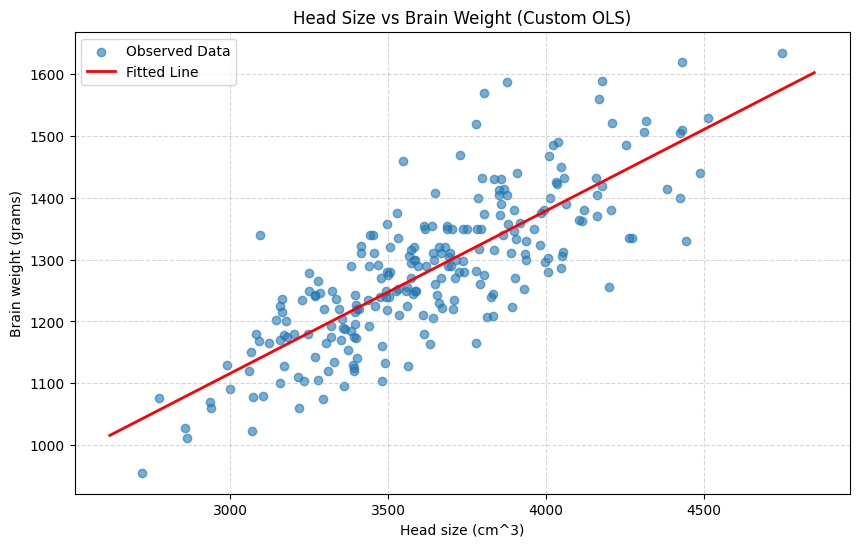

Root mean squared error: 72.121
R^2 value: 0.639


(np.float64(72.1206213783709), np.float64(0.639311719957))

In [41]:
# Read dataset
data = pd.read_csv("/content/headbrain.csv")
print("Shape:", data.shape)
print(data.head())

# Extract predictors as 1D arrays
X = data["Head Size(cm^3)"].values
y = data["Brain Weight(grams)"].values

# Create model, fit, plot, and evaluate
model = LinearRegression()
model.fit(X, y)
regression_plot(X, y, model, title="Head Size vs Brain Weight (Custom OLS)")
model.evaluate(X, y)

In [42]:
# column extraction
X = data['Head Size(cm^3)'].to_numpy()
y = data['Brain Weight(grams)'].to_numpy()

(b0, b1) = (325.573, 0.263)


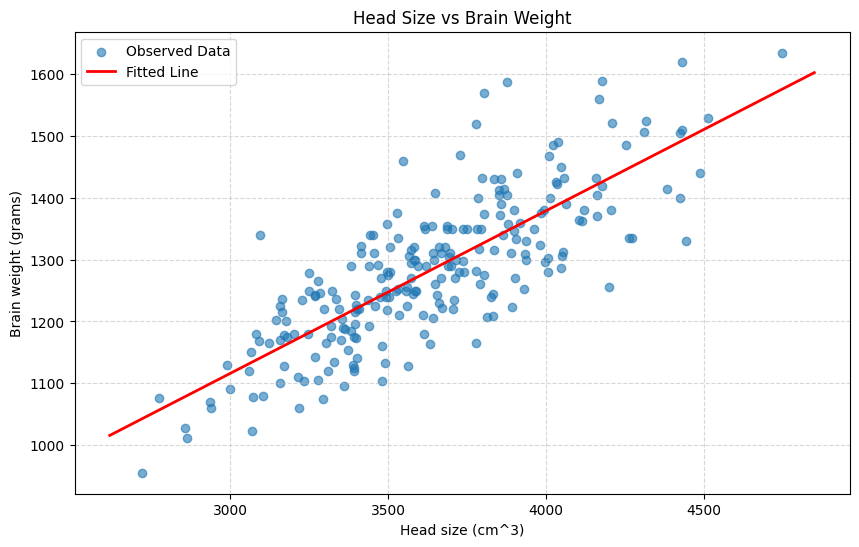

Root mean squared error: 72.121
R^2 value: 0.639


(np.float64(72.1206213783709), np.float64(0.639311719957))

In [43]:
# model
model = LinearRegression()

# fit
model.fit(X,y)

# plot
regression_plot(X, y, model, title="Head Size vs Brain Weight")

# evaluate
model.evaluate(X,y)

Task - A4

In [44]:
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.metrics import mean_squared_error

X1 = X.reshape(-1, 1)

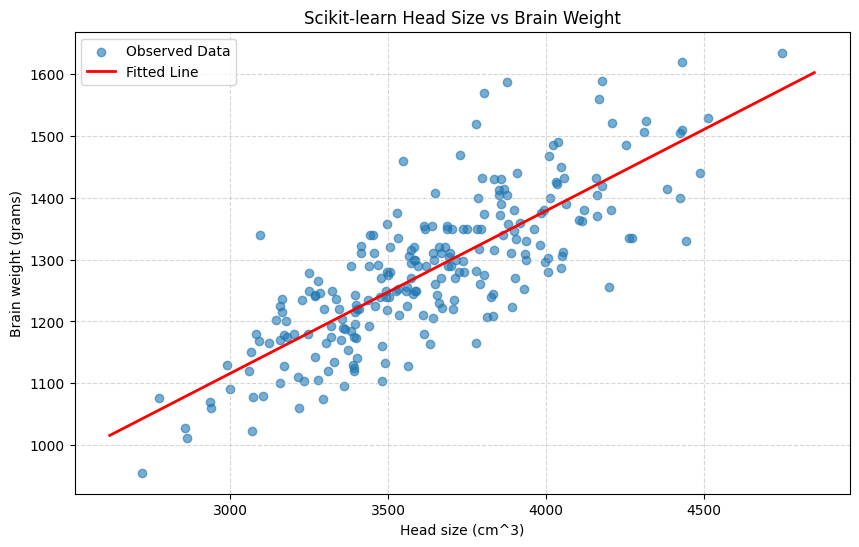

Intercept: 325.573
Coefficient: 0.263
RMSE = 72.121
R^2  = 0.639
Absolute difference in b0: 2.2737367544323206e-13
Absolute difference in b1: 5.551115123125783e-17


In [46]:
# fitting model
sk_model = SkLinearRegression()
sk_model.fit(X1, y)

# plotting
plt.figure(figsize=(10, 6))
plt.title("Scikit-learn Head Size vs Brain Weight")
plt.xlabel("Head size (cm^3)")
plt.ylabel("Brain weight (grams)")

# Re-creating x_line and reshaping for sklearn model
x_min, x_max = np.min(X1), np.max(X1)
margin = (x_max - x_min) * 0.05
x_line_2d = np.array([x_min - margin, x_max + margin]).reshape(-1, 1) # Reshape to 2D
y_line_sk = sk_model.predict(x_line_2d)

plt.scatter(X1, y, alpha=0.6, label="Observed Data")
plt.plot(x_line_2d, y_line_sk, color="red", linewidth=2, label="Fitted Line")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# evaluation
y_pred_sk = sk_model.predict(X1)
rmse_sk = np.sqrt(mean_squared_error(y, y_pred_sk))
r2_sk = sk_model.score(X1, y)
print("Intercept:", round(sk_model.intercept_, 3))
print("Coefficient:", round(sk_model.coef_[0], 3))
print(f"RMSE = {rmse_sk:.3f}")
print(f"R^2  = {r2_sk:.3f}")

# absolute difference
print("Absolute difference in b0:", abs(model.b0 - sk_model.intercept_))
print("Absolute difference in b1:", abs(model.b1 - sk_model.coef_[0]))

Task - A5

In [48]:
from scipy.stats import t

def coefficient_standard_errors(X, y, model):
    m = len(X)
    y_pred = model.predict(X)
    residuals = y - y_pred

    # Residual variance with m - 2 degrees of freedom
    ss_res = np.sum(residuals ** 2)
    s2 = ss_res / (m - 2)

    x_mean = np.mean(X)
    sum_sq_x_diff = np.sum((X - x_mean) ** 2)

    se_b1 = np.sqrt(s2 / sum_sq_x_diff)
    se_b0 = np.sqrt(s2 * ((1 / m) + (x_mean ** 2 / sum_sq_x_diff)))

    return se_b0, se_b1

se_b0, se_b1 = coefficient_standard_errors(X, y, model)
m = len(X)
t_crit = t.ppf(0.975, df=m-2)  # Approximately ~1.96

ci_b0 = (model.b0 - t_crit * se_b0, model.b0 + t_crit * se_b0)
ci_b1 = (model.b1 - t_crit * se_b1, model.b1 + t_crit * se_b1)

print(f"b0 = {model.b0:.3f} +/- {t_crit * se_b0:.3f}  (95% CI: [{ci_b0[0]:.3f}, {ci_b0[1]:.3f}])")
print(f"b1 = {model.b1:.3f} +/- {t_crit * se_b1:.3f}  (95% CI: [{ci_b1[0]:.3f}, {ci_b1[1]:.3f}])")

b0 = 325.573 +/- 92.873  (95% CI: [232.701, 418.446])
b1 = 0.263 +/- 0.025  (95% CI: [0.238, 0.289])


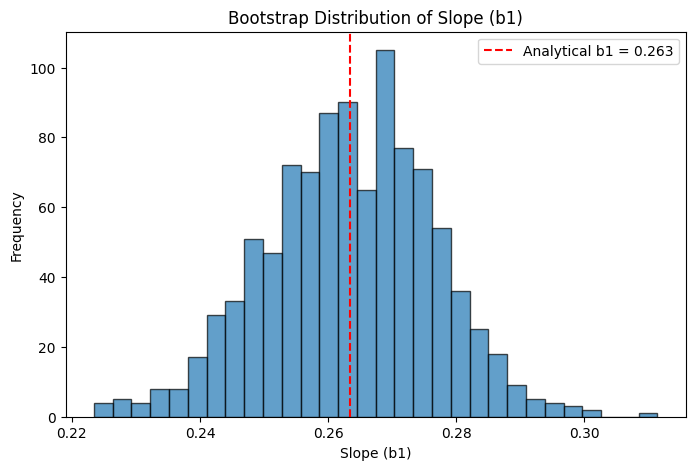

Analytical SE(b1): 0.01291
Bootstrap  SE(b1): 0.01316


In [50]:
def bootstrap_slope(X, y, n_resamples=1000, seed=0):
    rng = np.random.default_rng(seed)
    m = len(X)
    slopes = np.zeros(n_resamples)

    for i in range(n_resamples):
        indices = rng.integers(0, m, size=m)
        X_boot, y_boot = X[indices], y[indices]

        # Calculate slope b1 directly for performance
        x_mean, y_mean = np.mean(X_boot), np.mean(y_boot)
        b1 = np.dot(X_boot - x_mean, y_boot - y_mean) / np.sum((X_boot - x_mean) ** 2)
        slopes[i] = b1

    return slopes

boot_slopes = bootstrap_slope(X, y, n_resamples=1000, seed=0)
boot_se_b1 = np.std(boot_slopes, ddof=1)

plt.figure(figsize=(8, 5))
plt.hist(boot_slopes, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(model.b1, color="red", linestyle="--", label=f"Analytical b1 = {model.b1:.3f}")
plt.title("Bootstrap Distribution of Slope (b1)")
plt.xlabel("Slope (b1)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Analytical SE(b1): {se_b1:.5f}")
print(f"Bootstrap  SE(b1): {boot_se_b1:.5f}")

Task - A6

ANSWER A61. Units and Physical Meaning of the Slope ($b_1$)Units: $\text{g/cm}^3$ (grams per cubic centimeter).Explanation: The slope $b_1$ represents the estimated increase in brain weight in grams for every $1\text{ cm}^3$ increase in head size.2. Reasons Why $R^2 < 1$Biological Variability: Factors such as age, gender, genetics, and overall physical build cause natural variation in brain weight among individuals with identical head sizes.Measurement Noise: Observational errors when measuring head volume and post-mortem brain weight introduce random noise into the dataset.3. Effect of Changing Units to Cubic Metres ($\text{m}^3$)$b_1$ (Slope): Multiplies by $10^6$ (scales up to match the unit change from $\text{g/cm}^3$ to $\text{g/m}^3$).$b_0$ (Intercept): Unchanged, because $b_0 = \bar{y} - b_1 \bar{x}$ automatically balances out the unit scale.$\text{RMSE}$: Unchanged, because the response variable $y$ remains measured in grams.$R^2$ Score: Unchanged, as linear scaling of input features does not affect the proportion

**LOGISTIC REGRESSION**

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic_df = pd.read_csv("titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Task - B1

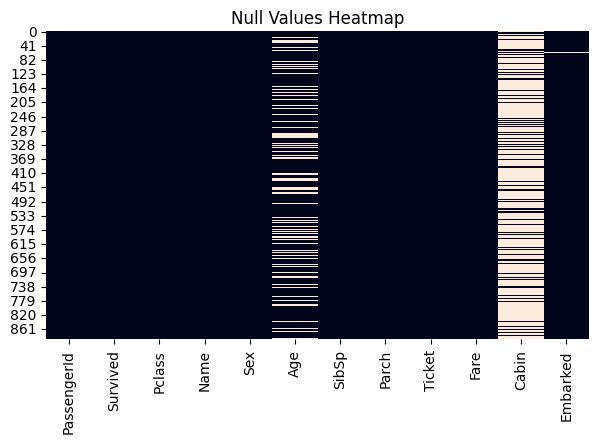

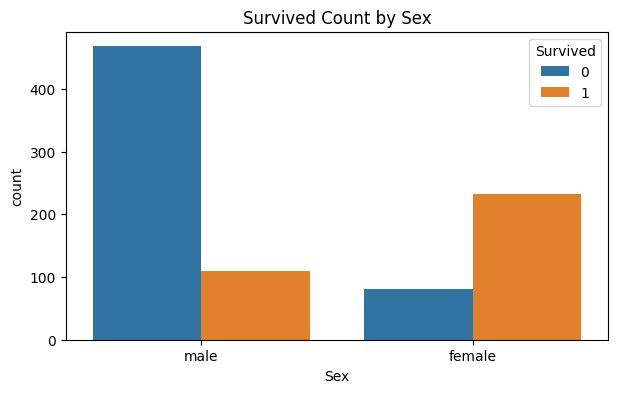

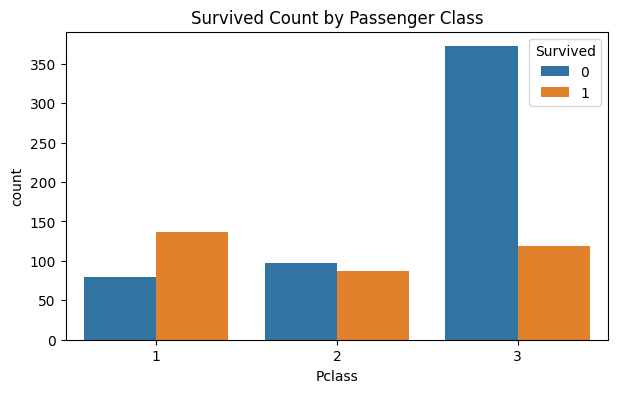

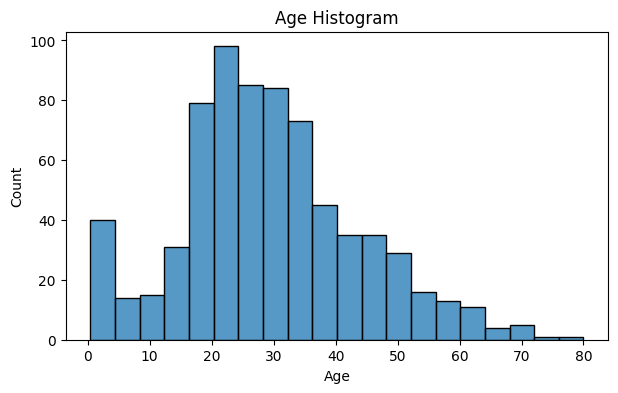

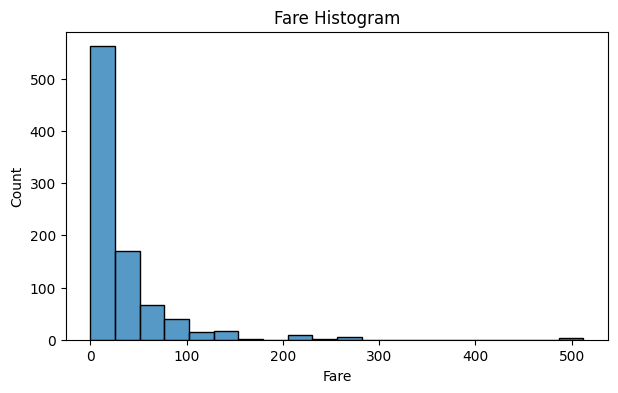

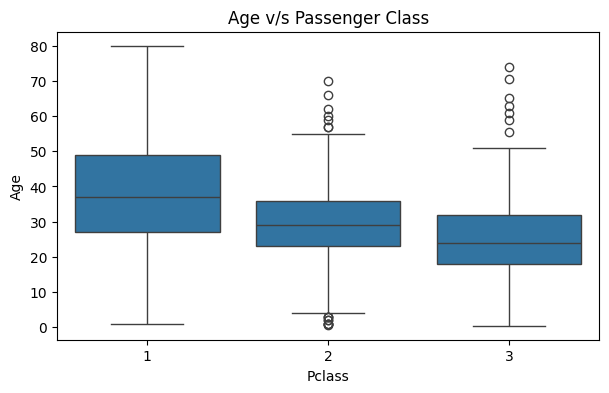

In [52]:
def plot(title, plot_func, *args, **kwargs):
    plt.figure(figsize=(7, 4))
    plt.title(title)
    plot_func(*args, **kwargs)
    plt.show()

# heatmap null values
plot("Null Values Heatmap", sns.heatmap, titanic_df.isnull(), cbar=False)

# count plot survived by sex
plot("Survived Count by Sex", sns.countplot, data=titanic_df, x="Sex", hue="Survived")

# count plot survived by pclass
plot("Survived Count by Passenger Class", sns.countplot, data=titanic_df, x="Pclass", hue="Survived")

# histogram of age
plot("Age Histogram", sns.histplot, data=titanic_df["Age"].dropna(), bins=20)

# histogram fare
plot("Fare Histogram", sns.histplot, data=titanic_df["Fare"], bins=20)

# box plot of age vs pclass
plot("Age v/s Passenger Class", sns.boxplot, data=titanic_df, x="Pclass", y="Age")

The columns of Age, Cabin, and Embarked contain null values. The box plot of Age vs Passenger Class shows that median class decreases as the passenger class increases. Secondly, passenger class 2 and 3 have several outliers which are absent in passenger class 1.

/tmp/ipykernel_3106/129870614.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = cols[0]
/tmp/ipykernel_3106/129870614.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pclass = cols[1]


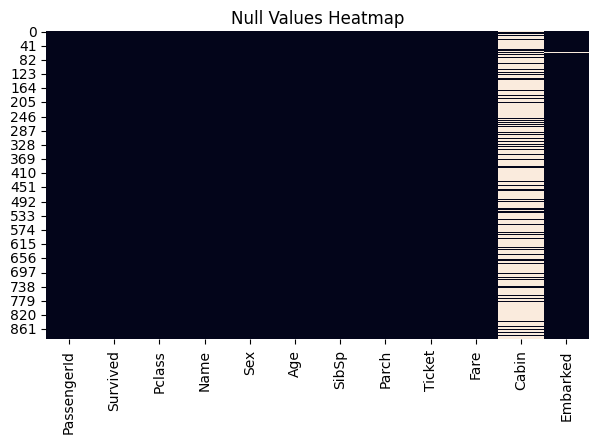

In [53]:
# dictionary for mean ages
mean_ages = titanic_df.groupby("Pclass")["Age"].mean().to_dict()

# imputing the missing age
def impute_age(cols):
    age = cols[0]
    pclass = cols[1]

    if pd.isnull(age):
        return mean_ages[pclass]
    else:
        return age

# applying the function
titanic_df["Age"] = titanic_df[["Age", "Pclass"]].apply(impute_age, axis=1)

# redrawing the heatmap
plot("Null Values Heatmap", sns.heatmap, titanic_df.isnull(), cbar=False)

In [54]:
# dropping the cabin column
titanic_df = titanic_df.drop(columns=["Cabin"])
titanic_df = titanic_df.dropna()

# one hot encode
encode_columns = pd.get_dummies(
    titanic_df[["Sex", "Embarked"]],
    drop_first=True
)

titanic_df = pd.concat(
    [titanic_df, encode_columns],
    axis=1
)

# dropping irrelevant columns
titanic_df = titanic_df.drop(columns=["Name", "PassengerId", "Ticket", "Sex", "Embarked"])

# displaying head
titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


drop_first = True is used to make sure that when dummy columns are created, it drops the first one as it is not needed. So instead of getting sex_male and sex_female, we would only get sex_male with 0/1 as entries. Both columns give us duplicate information.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import minmax_scale

In [56]:
# rescaling age and fare
titanic_df["Age"] = minmax_scale(titanic_df["Age"])
titanic_df["Fare"] = minmax_scale(titanic_df["Fare"])

# separating predictors and target
X = titanic_df.drop(columns=["Survived"])
y = titanic_df["Survived"]

# splitting data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# model fitting
model = LogisticRegression()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.83      0.80       157
           1       0.73      0.67      0.70       110

    accuracy                           0.76       267
   macro avg       0.76      0.75      0.75       267
weighted avg       0.76      0.76      0.76       267

[[130  27]
 [ 36  74]]


In [57]:
for seed in [12, 25, 40]:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
  model = LogisticRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = model.score(X_test, y_test)
  print(f"Seed = {seed}")
  print(f"Accuracy = {accuracy}")
  print()

Seed = 12
Accuracy = 0.8127340823970037

Seed = 25
Accuracy = 0.7565543071161048

Seed = 40
Accuracy = 0.8052434456928839





1.   True Negative (TN) = 130, False Positive (FP) = 27, False Negative (FN) = 36, and True Positive (TP) = 74.
2.   Precision tells us of all the passengers that the model predicted survived, how many actually survived.
Precision = TP/(TP+FP)
On the other hand, recall tells us, of all the passengers who actually survived, how many did model correctly identify.
Recall = TP/(TP+FN)
3. Highest accuracy = 81.27% and lowest accuracy = 75.66%. Thus the spread = 5.61% points. This shows that the model's accuracy does depend on how data is split into training and testing data. Thus, an accuracy from a single random state does not give a full picture.



Task - B5

In [58]:
import numpy as np
import pandas as pd

In [59]:
class LogitRegression:
    """Binary logistic regression trained by full batch gradient descent."""

    def __init__(self, learning_rate, iterations):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def p(self, X):
        """Return the predicted probability for a design matrix that already carries
        the leading column of ones."""
        return 1/(1 + np.exp(-(X @ self.w)))

    def fit(self, X, y):
        m, n = X.shape
        X = np.hstack([np.ones((m, 1)), X])
        y = y.squeeze()
        self.w = np.zeros(n + 1)
        for _ in range(self.iterations):
            gradient = (X.T @ (self.p(X) - y)) / m
            self.w = self.w - self.learning_rate * gradient
        return self

    def predict(self, X):
        """Return the predicted class label, 0 or 1, for each row of X."""
        m = X.shape[0]
        X = np.hstack([np.ones((m, 1)), X])
        return (self.p(X) >= 0.5).astype(int)

In [60]:
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

diabetes_df = pd.read_csv("diabetes.csv")
X = minmax_scale(diabetes_df.iloc[:, :-1].values)
y = diabetes_df.iloc[:, -1:].values.reshape(-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=6
)
print(X_train.shape, X_test.shape)

(512, 8) (256, 8)


In [61]:
def compute_accuracy(model, X_test, y_test):
    y_hat = model.predict(X_test)
    return (y_hat == y_test).mean() * 100

In [62]:
models = [
    LogitRegression(learning_rate=0.1, iterations=1000),
    LogisticRegression(),
]

for model in models:
    model.fit(X_train, y_train)
    accuracy = compute_accuracy(model, X_test, y_test)
    print(f"{model.__class__.__name__}: {accuracy:.2f}%")

LogitRegression: 74.22%
LogisticRegression: 78.91%


Task - B6

In [63]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

for lr in learning_rates:
    model = LogitRegression(learning_rate=lr, iterations=1000)
    model.fit(X_train, y_train)

    accuracy = compute_accuracy(model, X_test, y_test)
    print(f"Learning Rate: {lr}, Accuracy: {accuracy:.2f}%")

Learning Rate: 0.001, Accuracy: 67.58%
Learning Rate: 0.01, Accuracy: 67.58%
Learning Rate: 0.1, Accuracy: 74.22%
Learning Rate: 1.0, Accuracy: 77.34%


The test accuracy increases as the learning rate increases from 0.001 to 1.0. This suggests that model's weights are being updated very slowly. The learning rate of 1.0 gives the highest accuracy.